=== HASIL ANALISIS ===
Rata-rata intensitas asli      : 184.3318
Rata-rata intensitas restorasi : 184.3434
Selisih rata-rata intensitas   : 0.0117
Mean Squared Error (MSE)       : 49.6601


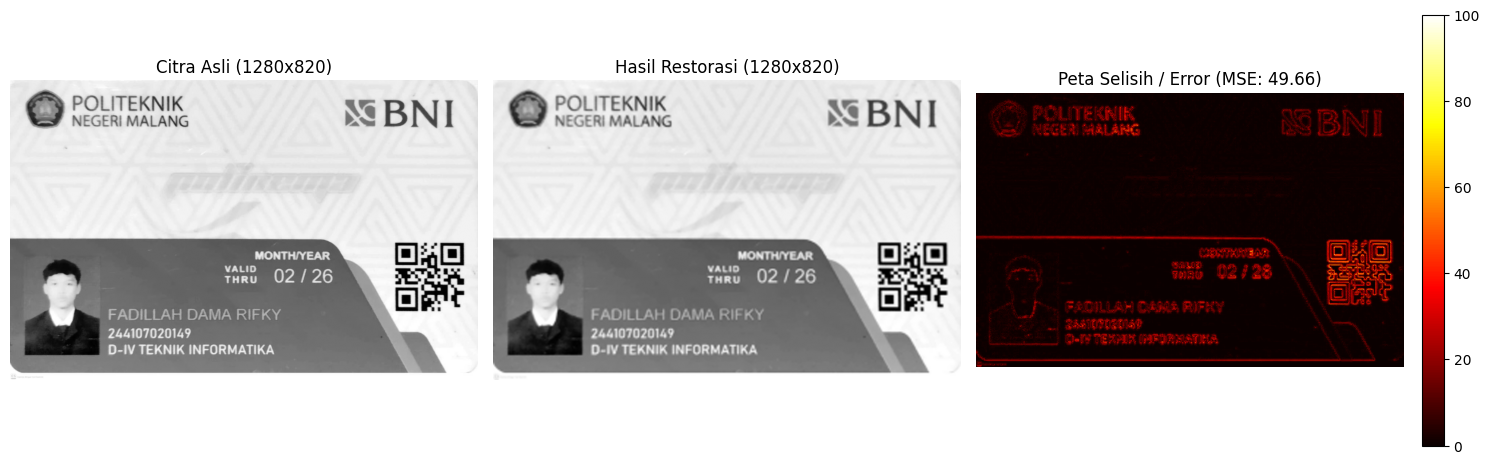

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Program Analisis
gray_asli = cv.imread('KTM.jpeg', cv.IMREAD_GRAYSCALE)
h_asli, w_asli = gray_asli.shape

# Downscale ke 25% lalu Upscale kembali ke 100%
gray_down = cv.resize(gray_asli, (w_asli // 4, h_asli // 4), interpolation=cv.INTER_AREA)
gray_restorasi = cv.resize(gray_down, (w_asli, h_asli), interpolation=cv.INTER_CUBIC)

rata_asli = np.mean(gray_asli)
rata_restorasi = np.mean(gray_restorasi)
perbedaan_rata = abs(rata_asli - rata_restorasi)
mse = np.mean((gray_asli.astype(np.float32) - gray_restorasi.astype(np.float32)) ** 2)

print("=== HASIL ANALISIS ===")
print(f"Rata-rata intensitas asli      : {rata_asli:.4f}")
print(f"Rata-rata intensitas restorasi : {rata_restorasi:.4f}")
print(f"Selisih rata-rata intensitas   : {perbedaan_rata:.4f}")
print(f"Mean Squared Error (MSE)       : {mse:.4f}")

# Menampilkan visualisasi gambar
plt.figure(figsize=(15, 5))

# Subplot 1: Citra Asli
plt.subplot(1, 3, 1)
plt.imshow(gray_asli, cmap='gray')
plt.title(f'Citra Asli ({w_asli}x{h_asli})')
plt.axis('off')

# Subplot 2: Citra Hasil Restorasi
plt.subplot(1, 3, 2)
plt.imshow(gray_restorasi, cmap='gray')
plt.title(f'Hasil Restorasi ({w_asli}x{h_asli})')
plt.axis('off')

# Subplot 3: Peta Perbedaan / Error
plt.subplot(1, 3, 3)
plt.imshow(selisih_gambar, cmap='hot')
plt.title(f'Peta Selisih / Error (MSE: {mse:.2f})')
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.tight_layout()
plt.show()

Kesimpulan: Interpolasi saat pembesaran kembali hanya memperkirakan nilai tetangga dan tidak dapat mengembalikan detail informasi frekuensi tinggi yang hilang saat downscaling. Rata-rata intensitas keseluruhan hanya bergeser sedikit, namun nilai piksel lokal mengalami perubahan signifikan (MSE > 0).